In [7]:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'transformers==4.41.0', '--break-system-packages', '-q'],
    capture_output=True, text=True
)
print(result.returncode)
print(result.stderr[-200:] if result.stderr else "Clean")

0

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



In [3]:
import torch
from chronos import ChronosBoltPipeline

print("Loading Chronos-Bolt...")
pipeline = ChronosBoltPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cpu",
    torch_dtype=torch.float32
)
print("Model loaded successfully")

Loading Chronos-Bolt...


c:\Users\NIHAAR\Desktop\fyp-environmental-forecasting\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded successfully


Data loaded

Forecasting NDVI Amazon...
  Forecast tensor shape: torch.Size([1, 9, 48])
  Forecast length: 48
  Actual length: 48


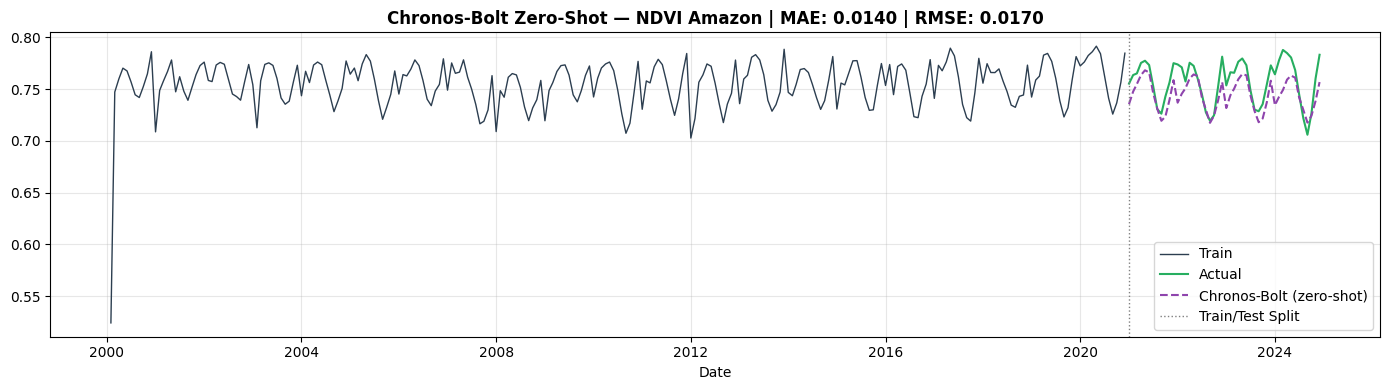


Forecasting NDVI Sahel...
  Forecast tensor shape: torch.Size([1, 9, 48])
  Forecast length: 48
  Actual length: 48


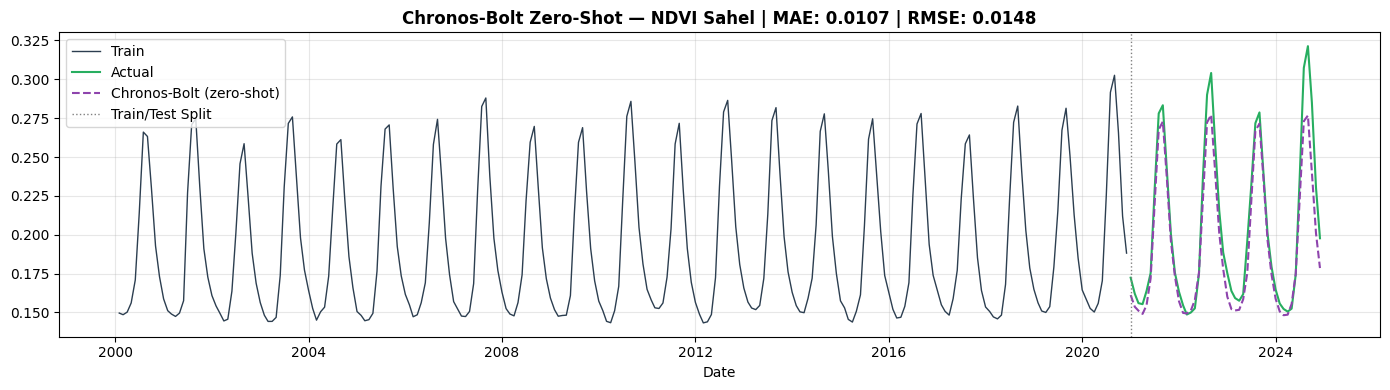


Forecasting SST North Atlantic...
  Forecast tensor shape: torch.Size([1, 9, 48])
  Forecast length: 48
  Actual length: 48


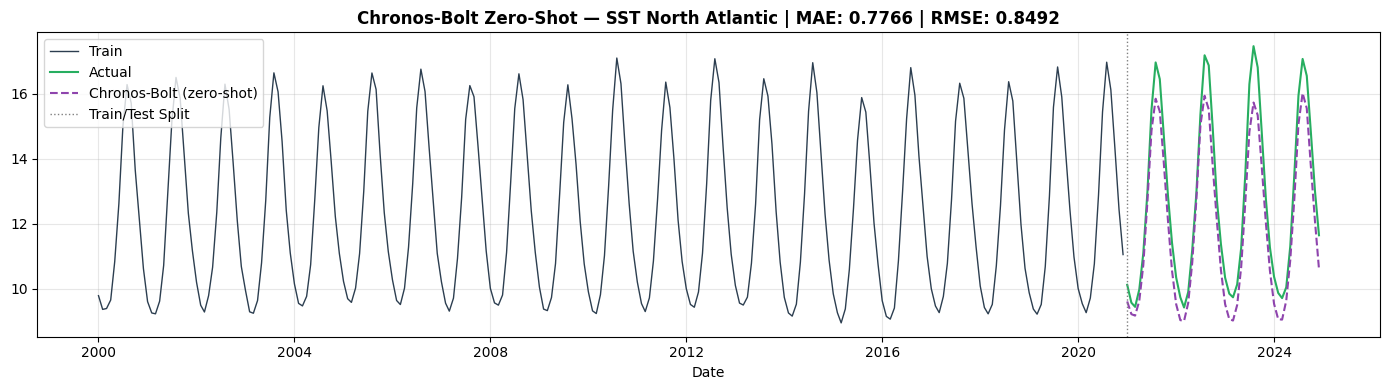


Forecasting SST Indian Ocean...
  Forecast tensor shape: torch.Size([1, 9, 48])
  Forecast length: 48
  Actual length: 48


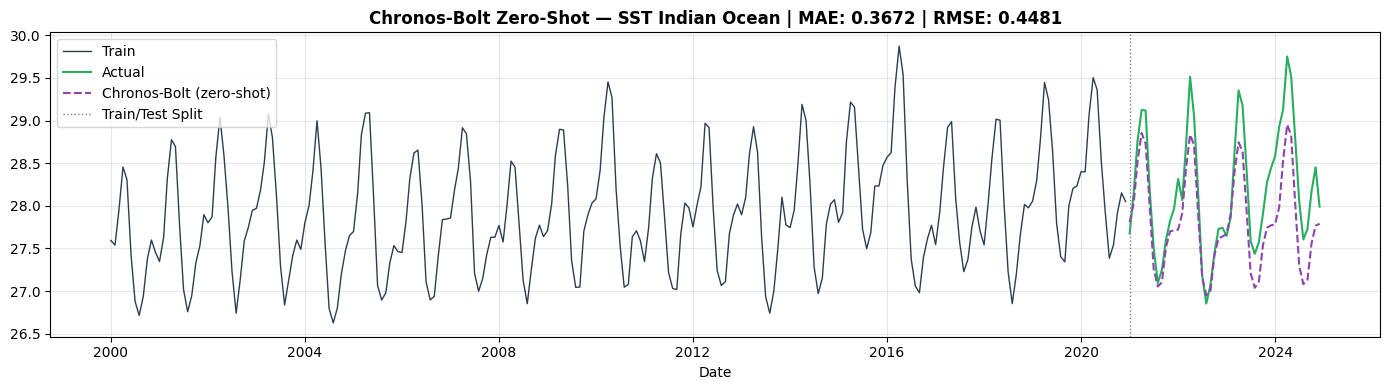


=== Chronos-Bolt Zero-Shot Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0140 0.0170
        NDVI Sahel 0.0107 0.0148
SST North Atlantic 0.7766 0.8492
  SST Indian Ocean 0.3672 0.4481


In [8]:
# ============================================================
# Chronos-Bolt — Zero-shot foundation model (Amazon, 2024)
# No training on our data — fed directly as context
# Tests whether a model trained on millions of diverse series
# can forecast satellite environmental data without fine-tuning
# Reference: Ansari et al. (2024) ICML, arxiv:2403.07815
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all series
ndvi_amazon_train  = pd.read_csv(DATA / 'ndvi_amazon_train.csv')
ndvi_amazon_test   = pd.read_csv(DATA / 'ndvi_amazon_test.csv')
ndvi_sahel_train   = pd.read_csv(DATA / 'ndvi_sahel_train.csv')
ndvi_sahel_test    = pd.read_csv(DATA / 'ndvi_sahel_test.csv')
sst_atlantic_train = pd.read_csv(DATA / 'sst_atlantic_train.csv')
sst_atlantic_test  = pd.read_csv(DATA / 'sst_atlantic_test.csv')
sst_indian_train   = pd.read_csv(DATA / 'sst_indian_train.csv')
sst_indian_test    = pd.read_csv(DATA / 'sst_indian_test.csv')

for df in [ndvi_amazon_train, ndvi_amazon_test, ndvi_sahel_train, ndvi_sahel_test,
           sst_atlantic_train, sst_atlantic_test, sst_indian_train, sst_indian_test]:
    df['date'] = pd.to_datetime(df['date'])

print("Data loaded")

def run_chronos(train, test, value_col, series_name):
    print(f"\nForecasting {series_name}...")

    inputs = [torch.tensor(train[value_col].values, dtype=torch.float32)]

    forecast_tensor = pipeline.predict(
        inputs=inputs,
        prediction_length=len(test),
        limit_prediction_length=False,
    )

    print(f"  Forecast tensor shape: {forecast_tensor.shape}")
    forecast = forecast_tensor[0].numpy().flatten()[:len(test)]
    print(f"  Forecast length: {len(forecast)}")

    actual = test[value_col].values
    print(f"  Actual length: {len(actual)}")

    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast,
            color='#8e44ad', linewidth=1.5, linestyle='--',
            label='Chronos-Bolt (zero-shot)')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Chronos-Bolt Zero-Shot — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"fig_chronos_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'series': series_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    }

# Run on all four series
results_chronos = []

results_chronos.append(run_chronos(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon'))

results_chronos.append(run_chronos(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel'))

results_chronos.append(run_chronos(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic'))

results_chronos.append(run_chronos(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean'))

results_chronos_df = pd.DataFrame(results_chronos)
print("\n=== Chronos-Bolt Zero-Shot Results ===")
print(results_chronos_df.to_string(index=False))